In [19]:
# ============================================================
# 03_spectral_diversity.ipynb
#
# Purpose:
#   1. Join relative reflectance spectra with quadrat metadata
#   2. Perform spectral quality control
#   3. Calculate within-quadrat spectral diversity using:
#        - spectral angle
#        - PCA dispersion
#        - coefficient of variation (CV)
#
# Spectral range: 400–900 nm
# Sampling unit: 1 m2 quadrat
# Spectral replicates: 3 per quadrat
# ============================================================


# 1. LIBRARIES AND FILE PATHS

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


processed_dir = (
    r"C:\Users\Gabriela Shirkey\OneDrive - Chapman University"
    r"\CONNECT_SBG\Coastal-Tanner\SpectralEvolution"
    r"\LCDM_2005_3A02\LCDM_2005_3A02_processed"
)


reflectance_file = os.path.join(
    processed_dir,
    "LCDM_050225_relative_reflectance.csv"
)


crosswalk_file = os.path.join(
    processed_dir,
    "LCDM_050225_filenames_joined_sed_photoids.csv"
)


print("Reflectance file:")
print(reflectance_file)

print("\nCrosswalk file:")
print(crosswalk_file)

Reflectance file:
C:\Users\Gabriela Shirkey\OneDrive - Chapman University\CONNECT_SBG\Coastal-Tanner\SpectralEvolution\LCDM_2005_3A02\LCDM_2005_3A02_processed\LCDM_050225_relative_reflectance.csv

Crosswalk file:
C:\Users\Gabriela Shirkey\OneDrive - Chapman University\CONNECT_SBG\Coastal-Tanner\SpectralEvolution\LCDM_2005_3A02\LCDM_2005_3A02_processed\LCDM_050225_filenames_joined_sed_photoids.csv


In [20]:
# 2. READ REFLECTANCE AND CROSSWALK DATA

reflectance_df = pd.read_csv(reflectance_file)
crosswalk_df = pd.read_csv(crosswalk_file)

print("Reflectance shape:", reflectance_df.shape)
print("Crosswalk shape:", crosswalk_df.shape)

print("\nReflectance columns:")
print(reflectance_df.columns[:10])

print("\nCrosswalk preview:")
display(crosswalk_df.head())

#501 rows = wavelengths 400-900nm
#178 columns of "wavelength" name + 177 spectra

#177 rows = 177 spectra
#8 columns = filename + photo/quadrat/lat/long

Reflectance shape: (501, 178)
Crosswalk shape: (177, 8)

Reflectance columns:
Index(['wavelength', '1594452_00097', '1594452_00098', '1594452_00099',
       '1594452_00100', '1594452_00101', '1594452_00102', '1594452_00103',
       '1594452_00104', '1594452_00105'],
      dtype='object')

Crosswalk preview:


,filename,photo_id,latitude,longitude,distance_m,transect,quadrat_id,replicate
0,1594452_00097,IMG_2404.JPG,33.589467,-117.868247,0,1,1,1
1,1594452_00098,IMG_2404.JPG,33.589467,-117.868247,0,1,1,2
2,1594452_00099,IMG_2404.JPG,33.589467,-117.868247,0,1,1,3
3,1594452_00100,IMG_2405.JPG,33.589403,-117.868331,10,1,2,1
4,1594452_00101,IMG_2405.JPG,33.589403,-117.868331,10,1,2,2


In [21]:
# 3. VERIFY REFLECTANCE SPECTRA MATCH CROSSWALK FILENAMES

# All columns except "wavelength" are individual SED spectra
reflectance_filenames = reflectance_df.columns.drop("wavelength").tolist()

# Individual SED filenames from the crosswalk
crosswalk_filenames = crosswalk_df["filename"].tolist()

print("Reflectance spectra:", len(reflectance_filenames))
print("Crosswalk spectra:", len(crosswalk_filenames))

print(
    "Same filenames:",
    set(reflectance_filenames) == set(crosswalk_filenames)
)

print(
    "Same order:",
    reflectance_filenames == crosswalk_filenames
)

# Stop here if anything is inconsistent
assert len(reflectance_filenames) == 177
assert len(crosswalk_filenames) == 177
assert set(reflectance_filenames) == set(crosswalk_filenames)

print("\nAll 177 reflectance spectra have matching crosswalk records.")

Reflectance spectra: 177
Crosswalk spectra: 177
Same filenames: True
Same order: True

All 177 reflectance spectra have matching crosswalk records.


In [22]:
# 4. SELECT 15 QUADRATS FOR SPECTRAL QC QUICK GUT CHECK

qc_quadrats = [
    # Near shore: 0–10 m
    1,    # T1,  0 m
    8,    # T2, 10 m
    25,   # T5,  0 m
    42,   # T8,  0 m
    49,   # T9, 10 m

    # Middle: 20–30 m
    3,    # T1, 20 m
    16,   # T3, 30 m
    27,   # T5, 20 m
    39,   # T7, 30 m
    57,   # T10, 20 m

    # Far shore: 40–50 m
    6,    # T1, 50 m
    23,   # T4, 40 m
    35,   # T6, 40 m
    52,   # T9, 40 m
    60    # T10, 50 m
]

qc_metadata = (
    crosswalk_df[
        crosswalk_df["quadrat_id"].isin(qc_quadrats)
    ]
    .sort_values(["quadrat_id", "replicate"])
)

print("Selected quadrats:", qc_metadata["quadrat_id"].nunique())
print("Selected spectra:", len(qc_metadata))

display(
    qc_metadata[
        ["filename", "quadrat_id", "transect", "distance_m", "replicate"]
    ]
)

Selected quadrats: 15
Selected spectra: 45


,filename,quadrat_id,transect,distance_m,replicate
0,1594452_00097,1,1,0,1
1,1594452_00098,1,1,0,2
2,1594452_00099,1,1,0,3
6,1594452_00103,3,1,20,1
7,1594452_00104,3,1,20,2
8,1594452_00105,3,1,20,3
15,1594452_00112,6,1,50,1
16,1594452_00113,6,1,50,2
17,1594452_00114,6,1,50,3
21,1594452_00118,8,2,10,1


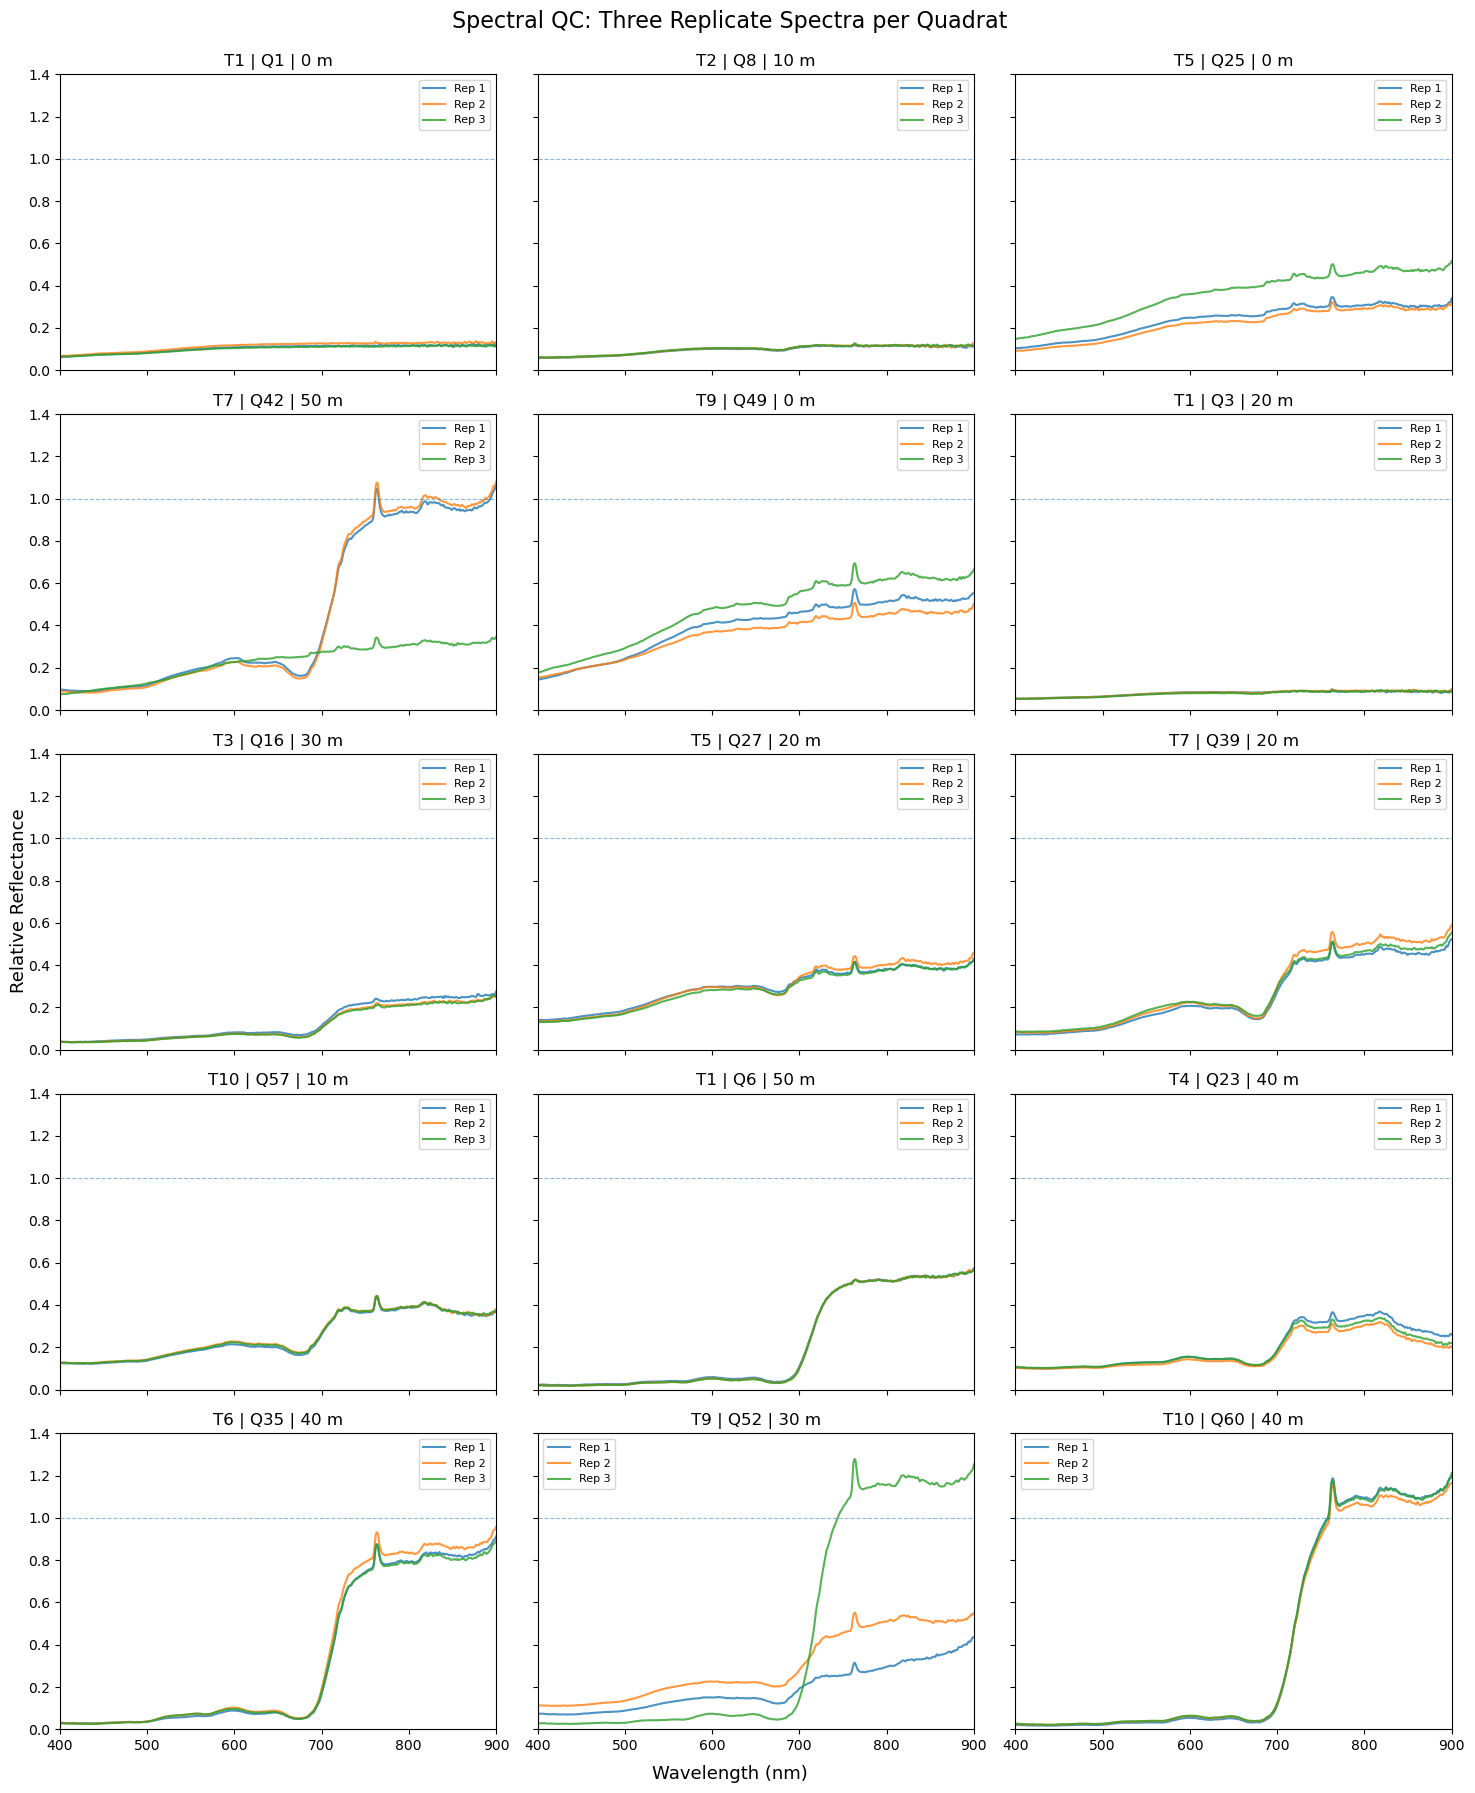

In [23]:
# 5. PLOT 15 QUADRATS FOR SPECTRAL QC QUICK GUT CHECK

fig, axes = plt.subplots(
    5, 3,
    figsize=(15, 18),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

wavelength = reflectance_df["wavelength"]

for ax, quadrat_id in zip(axes, qc_quadrats):

    # Get the 3 spectra belonging to this quadrat
    quadrat_meta = crosswalk_df[
        crosswalk_df["quadrat_id"] == quadrat_id
    ].sort_values("replicate")

    # Plot each replicate separately
    for _, row in quadrat_meta.iterrows():

        filename = row["filename"]
        replicate = row["replicate"]

        ax.plot(
            wavelength,
            reflectance_df[filename],
            label=f"Rep {replicate}",
            alpha=0.8
        )

    # Quadrat information for panel title
    transect = quadrat_meta["transect"].iloc[0]
    distance = quadrat_meta["distance_m"].iloc[0]

    ax.set_title(
        f"T{transect} | Q{quadrat_id} | {distance} m"
    )

    # White-reference level
    ax.axhline(
        y=1,
        linestyle="--",
        linewidth=0.8,
        alpha=0.5
    )

    ax.set_xlim(400, 900)
    ax.set_ylim(0, 1.4)
    ax.legend(fontsize=8)


fig.supxlabel("Wavelength (nm)", fontsize=13)
fig.supylabel("Relative Reflectance", fontsize=13)

fig.suptitle(
    "Spectral QC: Three Replicate Spectra per Quadrat",
    fontsize=16,
    y=0.995
)

plt.tight_layout()
plt.show()

QC note: Visual inspection of 15 quadrats spanning the shoreline-distance gradient showed generally consistent spectral shapes among within-quadrat replicates, with greater variability in some quadrats. No spectra were excluded based on visual inspection. High within-quadrat variability was retained as potentially meaningful spectral heterogeneity.

### First Spectral Div Metric --> Spectral Angle

Spectral angle measures the **dissimilarity in spectral shape** between two spectra by treating each spectrum as a multidimensional vector across wavelengths and calculating the angle between them.

- **Small angle** = spectra have similar spectral shapes
- **Large angle** = spectra are more spectrally dissimilar
- It is relatively insensitive to differences in overall brightness or magnitude.

For each quadrat, spectral angles are calculated between all three pairs of replicate spectra (1–2, 1–3, and 2–3), and the **mean pairwise spectral angle** is used as the quadrat-level measure of spectral dissimilarity.

For more info, see the Spectral Angle Mapper (SAM) equation originally described by Kruse et al. (1993) The Spectral Image Processing System (SIPS)—Interactive Visualization and Analysis of Imaging Spectrometer Data, Remote Sensing of Environment 44:145–163.

In [24]:
# 6. CALCULATE WITHIN-QUADRAT SPECTRAL ANGLE

def spectral_angle(spectrum1, spectrum2):
    """
    Calculate spectral angle between two spectra.

    Returns angle in degrees:
        0 degrees = identical spectral shape
        larger angle = greater spectral dissimilarity
    """

    # Dot product of the two spectral vectors
    numerator = np.dot(spectrum1, spectrum2) # this is x * y, where np.dot matches the wavelengths in the vector

    # Product of their vector lengths; this is ||x|| ||y||
    denominator = (
        np.linalg.norm(spectrum1) *
        np.linalg.norm(spectrum2)
    )

    # Calculate cosine of the angle, this is the inverse cosine giving the spectral angle
    cosine_angle = numerator / denominator

    # Protect against tiny floating-point errors outside [-1, 1]
    cosine_angle = np.clip(cosine_angle, -1.0, 1.0)

    # Convert angle from radians to degrees
    return np.degrees(np.arccos(cosine_angle))


# Store one result per quadrat
spectral_angle_results = []


for quadrat_id, group in crosswalk_df.groupby("quadrat_id"):

    # Make sure replicates are in order 1, 2, 3
    group = group.sort_values("replicate")

    filenames = group["filename"].tolist()

    # Extract the three 400–900 nm reflectance spectra
    spectra = [
        reflectance_df[filename].to_numpy()
        for filename in filenames
    ]

    # Three pairwise spectral angles
    angle_12 = spectral_angle(spectra[0], spectra[1])
    angle_13 = spectral_angle(spectra[0], spectra[2])
    angle_23 = spectral_angle(spectra[1], spectra[2])

    mean_angle = np.mean([
        angle_12,
        angle_13,
        angle_23
    ])

    spectral_angle_results.append({
        "quadrat_id": quadrat_id,
        "transect": group["transect"].iloc[0],
        "distance_m": group["distance_m"].iloc[0],
        "angle_12_deg": angle_12,
        "angle_13_deg": angle_13,
        "angle_23_deg": angle_23,
        "mean_spectral_angle_deg": mean_angle
    })


spectral_angle_df = pd.DataFrame(spectral_angle_results)


print("Quadrats calculated:", len(spectral_angle_df))

display(
    spectral_angle_df.head(10)
)

Quadrats calculated: 59


,quadrat_id,transect,distance_m,angle_12_deg,angle_13_deg,angle_23_deg,mean_spectral_angle_deg
0,1,1,0,1.095356,1.007283,1.272799,1.125146
1,2,1,10,0.412834,0.474417,0.387953,0.425068
2,3,1,20,1.746551,2.084984,1.466357,1.765964
3,4,1,30,0.998964,1.048962,0.877268,0.975065
4,5,1,40,2.002735,1.468309,0.900879,1.457308
5,6,1,50,0.730020,0.876899,0.398435,0.668452
6,7,2,0,2.188708,3.031021,1.136358,2.118695
7,8,2,10,1.344698,1.224241,1.187648,1.252196
8,9,2,20,1.058636,0.985431,1.268267,1.104111
9,10,2,30,6.892283,8.372378,1.594731,5.619797


In [25]:
# 7. INSPECT DISTRIBUTION OF QUADRAT-LEVEL SPECTRAL ANGLE

print("Mean spectral angle summary (degrees):")
display(
    spectral_angle_df["mean_spectral_angle_deg"].describe()
)

print("\nQuadrats ranked from highest to lowest spectral angle:")
display(
    spectral_angle_df[
        [
            "quadrat_id",
            "transect",
            "distance_m",
            "mean_spectral_angle_deg", 
            "angle_12_deg",
            "angle_13_deg",
            "angle_23_deg"
        ]
    ]
    .sort_values(
        "mean_spectral_angle_deg",
        ascending=False
    )
    .reset_index(drop=True)
)

Mean spectral angle summary (degrees):


count    59.000000
mean      3.324404
std       4.950520
min       0.280657
25%       0.939661
50%       1.412895
75%       2.349153
max      21.540915
Name: mean_spectral_angle_deg, dtype: float64


Quadrats ranked from highest to lowest spectral angle:


,quadrat_id,transect,distance_m,mean_spectral_angle_deg,angle_12_deg,angle_13_deg,angle_23_deg
0,48,8,50,21.540915,2.628873,30.757339,31.236532
1,52,9,30,17.576632,5.853813,24.157256,22.718828
2,42,7,50,16.939777,1.238553,24.200066,25.380711
3,46,8,30,15.764114,0.754104,23.525598,23.012639
4,51,9,20,15.500013,4.221631,19.520873,22.757534
5,41,7,40,14.019578,4.818672,19.256921,17.983143
6,53,9,40,11.168902,15.837344,12.162959,5.506403
7,10,2,30,5.619797,6.892283,8.372378,1.594731
8,14,3,10,4.729392,6.882938,6.661990,0.643250
9,58,10,20,4.627696,1.167949,6.920503,5.794637


In [26]:
# 8. CHECK FOR SYSTEMATIC DIFFERENCES AMONG REPLICATE PAIRS

pairwise_angles = spectral_angle_df[
    ["angle_12_deg", "angle_13_deg", "angle_23_deg"]
]

summary = pairwise_angles.agg(
    ["mean", "median", "std", "min", "max"]
).T

summary["q25"] = pairwise_angles.quantile(0.25)
summary["q75"] = pairwise_angles.quantile(0.75)

summary = summary[
    ["mean", "median", "q25", "q75", "std", "min", "max"]
]

display(summary)

,mean,median,q25,q75,std,min,max
angle_12_deg,1.861868,1.095356,0.751367,1.913465,2.368219,0.320774,15.837344
angle_13_deg,4.418047,1.718729,0.996357,3.033769,6.945904,0.294933,30.757339
angle_23_deg,3.693298,1.187648,0.681936,2.027523,7.066345,0.221045,31.236532


### Spectral Diversity 2: PCA Spectral Dispersion

Principal component analysis (PCA) summarizes variation across the full 400–900 nm reflectance spectrum into a smaller number of orthogonal spectral dimensions (principal components).

Unlike spectral angle, which primarily measures differences in **spectral shape**, PCA retains variation associated with both **spectral shape and reflectance magnitude**.

PCA is fit using all 177 individual spectra, with wavelengths as variables. Reflectance values are mean-centered but not standardized because all wavelengths are measured in the same units and differences in spectral variance are considered meaningful.

Principal components explaining 95% of total spectral variance are retained. Within each quadrat, spectral dispersion is then calculated as the mean Euclidean distance of the three replicate spectra from their quadrat centroid in PCA space.

- **Small distance to centroid** = spectrally similar replicates
- **Large distance to centroid** = greater within-quadrat spectral heterogeneity

In [27]:
# 9. PCA OF ALL INDIVIDUAL SPECTRA

from sklearn.decomposition import PCA

# Create matrix:
# rows = 177 individual spectra
# columns = 501 wavelengths (400–900 nm)

X = (
    reflectance_df
    .set_index("wavelength")
    .T
)

# Put spectra in the same order as the crosswalk
X = X.loc[crosswalk_df["filename"]]

print("Spectral matrix shape:", X.shape)

# Fit PCA and retain enough components to explain 95%
# of the total variance in the spectral dataset.
#
# PCA mean-centers each wavelength automatically.
# We are intentionally NOT standardizing wavelengths.

pca = PCA(n_components=0.95)

pca_scores = pca.fit_transform(X)

print("\nNumber of PCs retained:", pca.n_components_)
print(
    "Cumulative variance explained:",
    pca.explained_variance_ratio_.sum()
)

print("\nVariance explained by each retained PC:")

for i, variance in enumerate(
    pca.explained_variance_ratio_,
    start=1
):
    print(
        f"PC{i}: {variance * 100:.2f}%"
    )

Spectral matrix shape: (177, 501)

Number of PCs retained: 2
Cumulative variance explained: 0.9878099046926184

Variance explained by each retained PC:
PC1: 78.69%
PC2: 20.09%


In [28]:
# 10. CALCULATE WITHIN-QUADRAT PCA DISPERSION

# Create dataframe containing PC scores for each individual spectrum
pca_scores_df = pd.DataFrame(
    pca_scores,
    columns=["PC1", "PC2"]
)

# Add spectrum filename so we can connect PCA scores
# back to quadrat metadata
pca_scores_df["filename"] = crosswalk_df["filename"].values

# Join quadrat information
pca_scores_df = pca_scores_df.merge(
    crosswalk_df[
        [
            "filename",
            "quadrat_id",
            "transect",
            "distance_m",
            "replicate"
        ]
    ],
    on="filename",
    how="left"
)

pca_dispersion_results = []

for quadrat_id, group in pca_scores_df.groupby("quadrat_id"):

    # Coordinates of the three spectra in PCA space
    coordinates = group[["PC1", "PC2"]].to_numpy()

    # Calculate the centroid of the three spectra
    centroid = coordinates.mean(axis=0)

    # Euclidean distance of each spectrum from the centroid
    distances = np.linalg.norm(
        coordinates - centroid,
        axis=1
    )

    pca_dispersion_results.append({
        "quadrat_id": quadrat_id,
        "transect": group["transect"].iloc[0],
        "distance_m": group["distance_m"].iloc[0],
        "pca_distance_rep1": distances[0],
        "pca_distance_rep2": distances[1],
        "pca_distance_rep3": distances[2],
        "mean_pca_dispersion": distances.mean()
    })

pca_dispersion_df = pd.DataFrame(
    pca_dispersion_results
)

print("Quadrats calculated:", len(pca_dispersion_df))

display(
    pca_dispersion_df
    .sort_values(
        "mean_pca_dispersion",
        ascending=False
    )
    .reset_index(drop=True)
)

Quadrats calculated: 59


,quadrat_id,transect,distance_m,pca_distance_rep1,pca_distance_rep2,pca_distance_rep3,mean_pca_dispersion
0,52,9,30,4.468810,2.295337,6.540421,4.434856
1,42,7,50,2.708625,3.007123,5.712240,3.809329
2,41,7,40,2.618191,2.540951,5.153564,3.437569
3,46,8,30,2.596287,2.333767,4.927441,3.285832
4,50,9,10,2.088233,2.002603,4.090330,2.727055
5,53,9,40,3.512279,1.639133,1.873350,2.341588
6,48,8,50,1.554440,1.781891,3.213552,2.183294
7,31,6,0,1.035355,1.133668,2.108447,1.425823
8,25,5,0,0.781955,1.220264,1.995825,1.332681
9,26,5,10,0.670541,1.952590,1.340864,1.321332


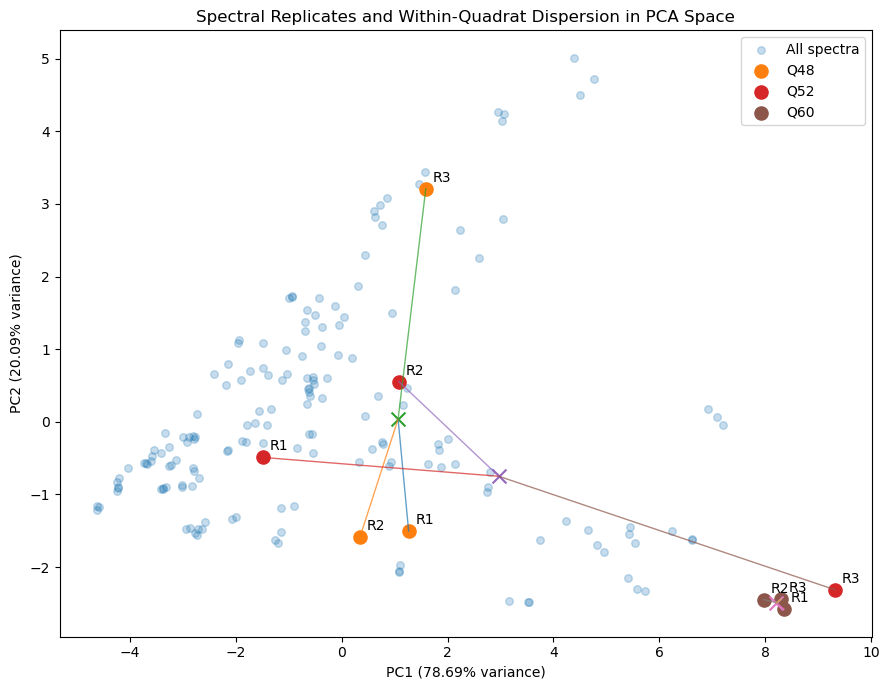

In [29]:
# 11. VISUALIZE REPLICATE SPECTRA IN PCA SPACE
# I highlight Q48, Q52, and Q60 because they have useful contrasts
# Q48 had the highest spectral angle, Q52 the highest PCA dispersion, and Q60 was very homogeneous

fig, ax = plt.subplots(figsize=(9, 7))

# Plot all 177 spectra in the background
ax.scatter(
    pca_scores_df["PC1"],
    pca_scores_df["PC2"],
    alpha=0.25,
    s=30,
    label="All spectra"
)

# Highlight selected quadrats
highlight_quadrats = [48, 52, 60]

for quadrat_id in highlight_quadrats:

    group = pca_scores_df[
        pca_scores_df["quadrat_id"] == quadrat_id
    ].sort_values("replicate")

    # Calculate quadrat centroid
    centroid_pc1 = group["PC1"].mean()
    centroid_pc2 = group["PC2"].mean()

    # Plot the three replicate spectra
    ax.scatter(
        group["PC1"],
        group["PC2"],
        s=90,
        label=f"Q{quadrat_id}"
    )

    # Connect each replicate to its quadrat centroid
    for _, row in group.iterrows():

        ax.plot(
            [row["PC1"], centroid_pc1],
            [row["PC2"], centroid_pc2],
            linewidth=1,
            alpha=0.7
        )

        # Label replicate number
        ax.annotate(
            f"R{int(row['replicate'])}",
            (row["PC1"], row["PC2"]),
            xytext=(5, 5),
            textcoords="offset points"
        )

    # Mark centroid
    ax.scatter(
        centroid_pc1,
        centroid_pc2,
        marker="x",
        s=100
    )

ax.set_xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0] * 100:.2f}% variance)"
)

ax.set_ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1] * 100:.2f}% variance)"
)

ax.set_title(
    "Spectral Replicates and Within-Quadrat Dispersion in PCA Space"
)

ax.legend()

plt.tight_layout()
plt.show()

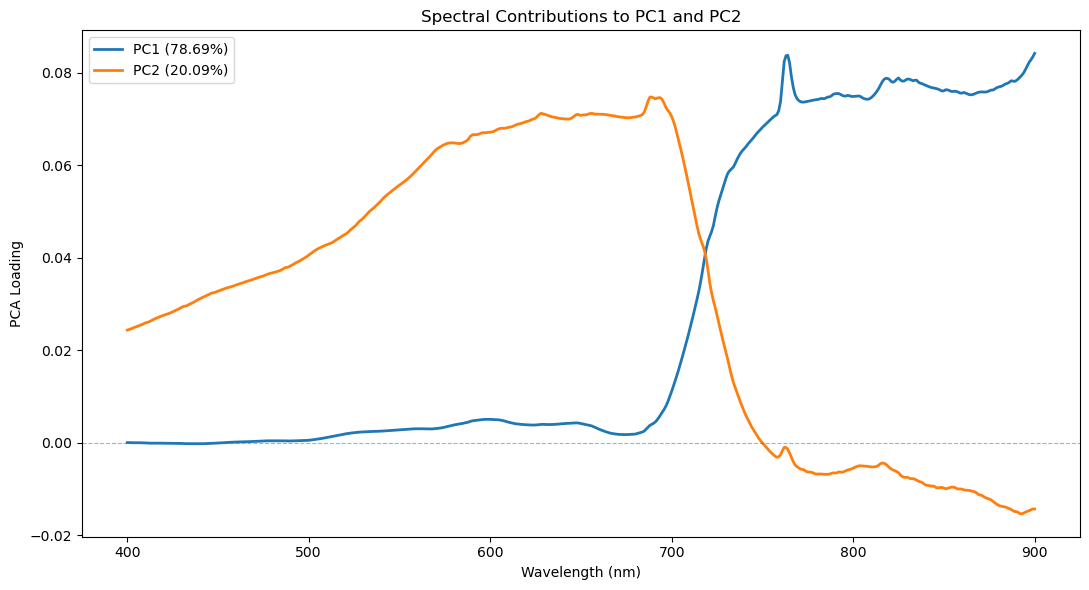

In [30]:
# 12. PLOT PCA LOADINGS ACROSS WAVELENGTHS
# Let's see what wavelengths in PC space explain the most spectral variability

wavelengths = X.columns.astype(float)

pc1_loadings = pca.components_[0]
pc2_loadings = pca.components_[1]

fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(
    wavelengths,
    pc1_loadings,
    label="PC1 (78.69%)",
    linewidth=2
)

ax.plot(
    wavelengths,
    pc2_loadings,
    label="PC2 (20.09%)",
    linewidth=2
)

# Reference line at zero loading
ax.axhline(
    0,
    linestyle="--",
    linewidth=0.8,
    alpha=0.5
)

ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("PCA Loading")

ax.set_title(
    "Spectral Contributions to PC1 and PC2"
)

ax.legend()

plt.tight_layout()
plt.show()

PC1: wavelengths in the visible (~400–700 nm) have very small loadings, while the red-edge/NIR (~700–900 nm) have much larger positive loadings. So variation in NIR reflectance contributes strongly to where a spectrum falls along PC1.

PC2: visible through ~700 nm has relatively strong positive loadings, which then decline sharply through the red edge and become slightly negative in the NIR. So PC2 contrasts visible/red-edge behavior against NIR behavior.

Save and export the spec div metrics

In [31]:
# Keep the quadrat-level spectral angle metrics
angle_out = spectral_angle_df[
    [
        "quadrat_id",
        "transect",
        "distance_m",
        "angle_12_deg",
        "angle_13_deg",
        "angle_23_deg",
        "mean_spectral_angle_deg"
    ]
].copy()

# Keep the quadrat-level PCA dispersion metrics
pca_out = pca_dispersion_df[
    [
        "quadrat_id",
        "mean_pca_dispersion"
    ]
].copy()

# Join by quadrat
spectral_diversity_df = angle_out.merge(
    pca_out,
    on="quadrat_id",
    how="left"
)

# Save
spectral_diversity_file = os.path.join(
    processed_dir,
    "LCDM_050225_quadrat_spectral_diversity.csv"
)

spectral_diversity_df.to_csv(
    spectral_diversity_file,
    index=False
)

print("Saved:", spectral_diversity_file)
print("Shape:", spectral_diversity_df.shape)

spectral_diversity_df.head()

Saved: C:\Users\Gabriela Shirkey\OneDrive - Chapman University\CONNECT_SBG\Coastal-Tanner\SpectralEvolution\LCDM_2005_3A02\LCDM_2005_3A02_processed\LCDM_050225_quadrat_spectral_diversity.csv
Shape: (59, 8)


,quadrat_id,transect,distance_m,angle_12_deg,angle_13_deg,angle_23_deg,mean_spectral_angle_deg,mean_pca_dispersion
0,1,1,0,1.095356,1.007283,1.272799,1.125146,0.112994
1,2,1,10,0.412834,0.474417,0.387953,0.425068,0.031022
2,3,1,20,1.746551,2.084984,1.466357,1.765964,0.028455
3,4,1,30,0.998964,1.048962,0.877268,0.975065,0.034472
4,5,1,40,2.002735,1.468309,0.900879,1.457308,0.075512
